#dataset loading and analysis



In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

data = fetch_ucirepo(id=165)

X = data.data.features
y = data.data.targets

In [3]:
import pandas as pd

df = pd.concat([X, y], axis=1)

In [4]:
df.head()

df.info()

df.isna().sum()

df.describe()

df.columns

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete compressive strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


(1030, 9)

In [5]:
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
1019,139.7,163.9,127.7,236.7,5.8,868.6,655.6,28,35.23
764,385.0,0.0,0.0,186.0,0.0,966.0,763.0,3,14.70
146,425.0,106.3,0.0,153.5,16.5,852.1,887.1,56,64.30
1021,298.2,0.0,107.0,209.7,11.1,879.6,744.2,28,31.88
627,200.0,0.0,0.0,180.0,0.0,1125.0,845.0,7,7.84


In [6]:
df.describe().T[["min", "max"]]

,min,max
Cement,102.00,540.0
Blast Furnace Slag,0.00,359.4
Fly Ash,0.00,200.1
Water,121.80,247.0
Superplasticizer,0.00,32.2
Coarse Aggregate,801.00,1145.0
Fine Aggregate,594.00,992.6
Age,1.00,365.0
Concrete compressive strength,2.33,82.6


# rawdataset visualization

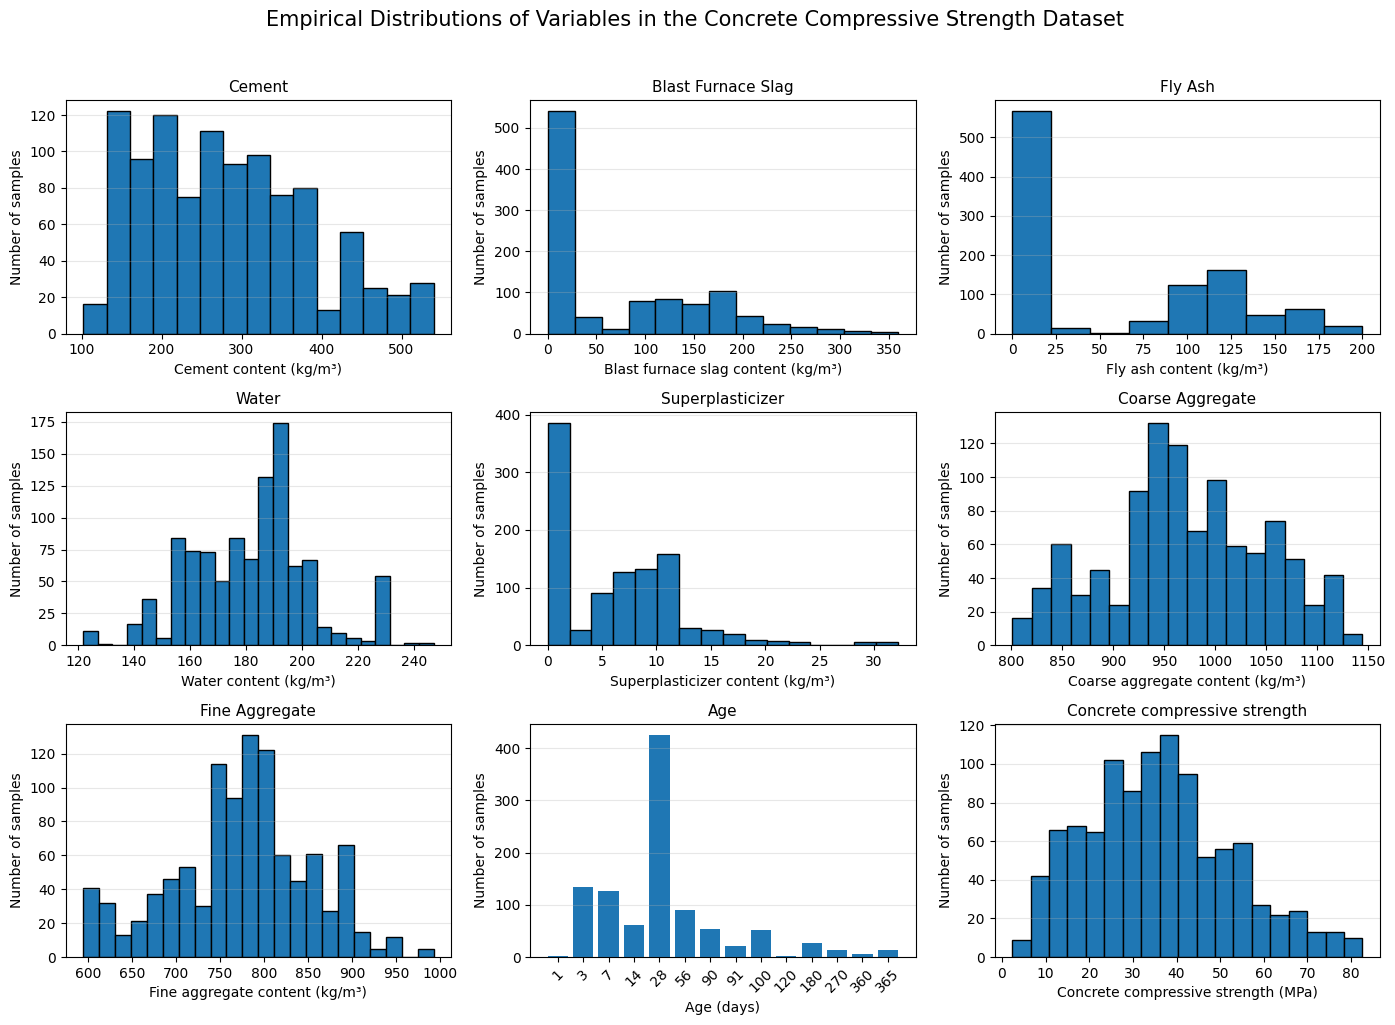

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

columns = [
    "Cement",
    "Blast Furnace Slag",
    "Fly Ash",
    "Water",
    "Superplasticizer",
    "Coarse Aggregate",
    "Fine Aggregate",
    "Age",
    "Concrete compressive strength"
]

x_labels = {
    "Cement": "Cement content (kg/m³)",
    "Blast Furnace Slag": "Blast furnace slag content (kg/m³)",
    "Fly Ash": "Fly ash content (kg/m³)",
    "Water": "Water content (kg/m³)",
    "Superplasticizer": "Superplasticizer content (kg/m³)",
    "Coarse Aggregate": "Coarse aggregate content (kg/m³)",
    "Fine Aggregate": "Fine aggregate content (kg/m³)",
    "Age": "Age (days)",
    "Concrete compressive strength": "Concrete compressive strength (MPa)"
}

def fd_bins(x):
    x = np.asarray(x.dropna())
    n = len(x)
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1

    if iqr == 0:
        return 10

    bin_width = 2 * iqr / (n ** (1 / 3))

    if bin_width == 0:
        return 10

    bins = int(np.ceil((x.max() - x.min()) / bin_width))
    return max(bins, 1)

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, columns):
    if col == "Age":
        counts = df[col].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values)
        ax.set_xlabel(x_labels[col])
        ax.tick_params(axis="x", rotation=45)
    else:
        bins = fd_bins(df[col])
        ax.hist(df[col], bins=bins, edgecolor="black")
        ax.set_xlabel(x_labels[col])

    ax.set_ylabel("Number of samples")
    ax.set_title(col, fontsize=11)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Empirical Distributions of Variables in the Concrete Compressive Strength Dataset",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.savefig("raw_dataset_histogram_grid_fd_rule.png", dpi=300, bbox_inches="tight")
plt.show()

# outlier check

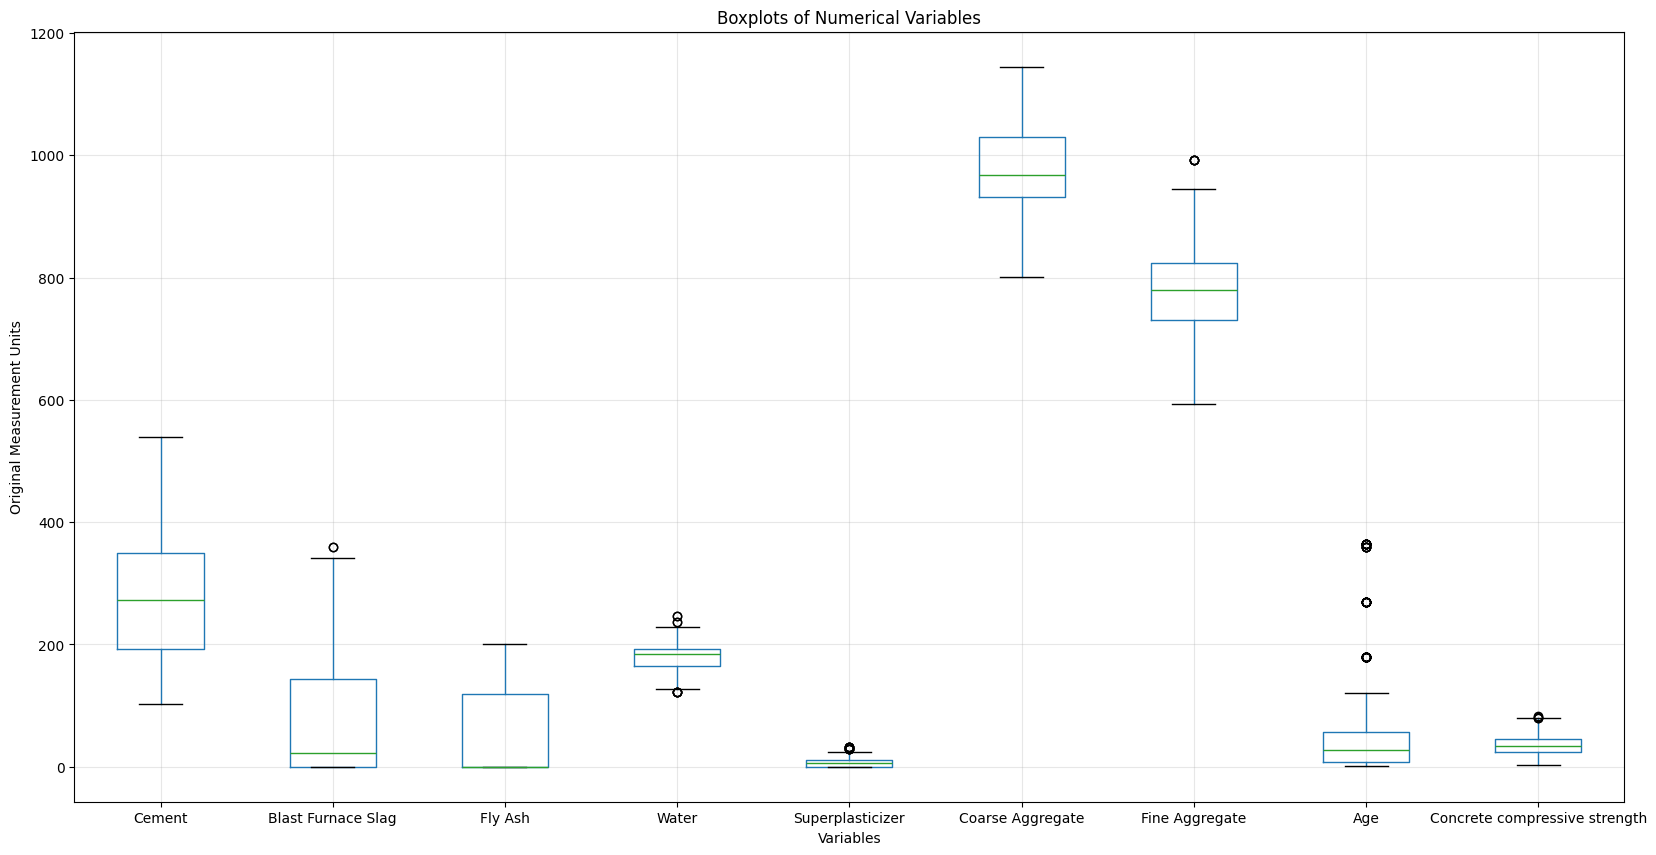

In [13]:
plt.figure(figsize=(20,10))

df.boxplot()

plt.xlabel("Variables")
plt.ylabel("Original Measurement Units")
plt.title("Boxplots of Numerical Variables")

plt.grid(alpha=0.3)

plt.show()

- The green line inside the box represents the median (Q2), corresponding to the 50th percentile.

- The lower edge of the box represents the first quartile (Q1), corresponding to the 25th percentile.

- The upper edge of the box represents the third quartile (Q3), corresponding to the 75th percentile.

- The upper whisker represents the largest non-outlier value, defined as:
  
  \[
  Q_3 + 1.5 \times IQR
  \]

- The lower whisker represents the smallest non-outlier value, defined as:
  
  \[
  Q_1 - 1.5 \times IQR
  \]

- The box contains the middle 50% of the data and its width corresponds to the interquartile range (IQR):
  
  \[
  IQR = Q_3 - Q_1
  \]

- The circles beyond the whiskers represent outliers.

In [14]:
def get_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return series[(series < lower) | (series > upper)]

cols = [
    "Blast Furnace Slag",
    "Water",
    "Superplasticizer",
    "Fine Aggregate",
    "Age",
    "Concrete compressive strength"
]

for col in cols:
    outliers = get_outliers(df[col])

    print("\n" + "="*50)
    print(col)
    print("Number of outliers:", len(outliers))
    print("Unique values:")
    print(sorted(outliers.unique()))


Blast Furnace Slag
Number of outliers: 2
Unique values:
[np.float64(359.4)]

Water
Number of outliers: 9
Unique values:
[np.float64(121.8), np.float64(236.7), np.float64(237.0), np.float64(246.9), np.float64(247.0)]

Superplasticizer
Number of outliers: 10
Unique values:
[np.float64(28.2), np.float64(32.2)]

Fine Aggregate
Number of outliers: 5
Unique values:
[np.float64(992.6)]

Age
Number of outliers: 59
Unique values:
[np.int64(180), np.int64(270), np.int64(360), np.int64(365)]

Concrete compressive strength
Number of outliers: 4
Unique values:
[np.float64(79.99), np.float64(80.2), np.float64(81.75), np.float64(82.6)]


In [16]:
age_outliers = get_outliers(df["Age"])

age_outliers.value_counts().sort_index()

,count
Age,
180,26
270,13
360,6
365,14


# (floc=0) strength distribution analysis & fitting -

In [ ]:
values = df["Concrete compressive strength"]

values.min(), values.max()

(2.33, 82.6)

In [ ]:
import numpy as np

values = df["Concrete compressive strength"]

q75, q25 = np.percentile(values, [75, 25])
iqr = q75 - q25
h = 2 * iqr / (len(values) ** (1/3))
print(h)

bins = np.arange(values.min(), values.max() + h, h)
len(bins)

4.441026579998705


20

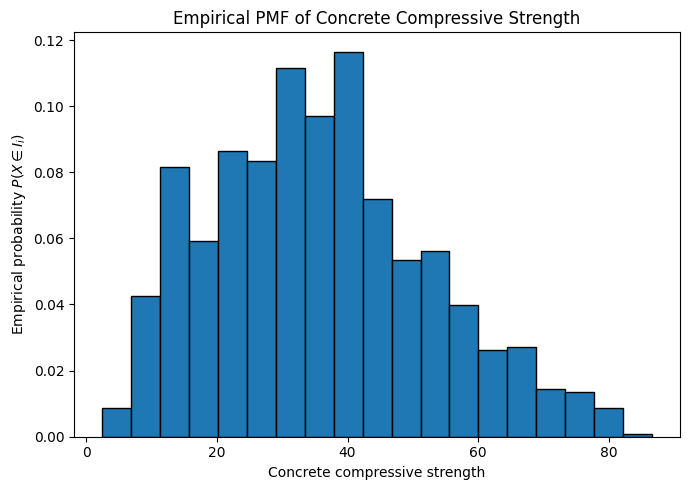

Sum of PMF: 1.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

counts, edges = np.histogram(values, bins=bins)

pmf = counts / counts.sum()

centers = (edges[:-1] + edges[1:]) / 2
widths = np.diff(edges)

plt.figure(figsize=(7, 5))
plt.bar(centers, pmf, width=widths, align="center", edgecolor="black")

plt.title("Empirical PMF of Concrete Compressive Strength")
plt.xlabel("Concrete compressive strength")
plt.ylabel(r"Empirical probability $P(X \in I_i)$")

plt.tight_layout()
plt.show()

print("Sum of PMF:", pmf.sum())

##PMF, moments

In [ ]:
hist, bin_edges = np.histogram(values, bins=bins)
pmf = hist / len(values)
print(pmf)

[0.00873786 0.04271845 0.0815534  0.0592233  0.08640777 0.08349515
 0.11165049 0.09708738 0.11650485 0.07184466 0.05339806 0.05631068
 0.03980583 0.02621359 0.02718447 0.01456311 0.01359223 0.00873786
 0.00097087]


In [ ]:
import scipy.stats as stats

mean = np.mean(values)
std = np.std(values)
skew = stats.skew(values)
kurt = stats.kurtosis(values)

print("mean:",mean)
print("std:",std)
print("skew:",skew)
print("kurt:",kurt)

mean: 35.817961165048544
std: 16.697630409134256
skew: 0.41636979411469355
kurt: -0.31802358543657805


## normal distributing fitting

Treat the normal distribution as one candidate model and evaluate how well it fits the data.

N(mean,standardeviation)

In [ ]:
from scipy.stats import norm

normal_probs = norm.cdf(bin_edges[1:], mean, std) - norm.cdf(bin_edges[:-1], mean, std)

rmse_normal = np.sqrt(np.mean((pmf - normal_probs) ** 2))

print("normal_probs:", normal_probs)
print("RMSE normal:", rmse_normal)

normal_probs: [0.01851398 0.02932638 0.04329869 0.05958669 0.07643323 0.09138481
 0.10184151 0.10578763 0.10242457 0.09243419 0.07775354 0.06096303
 0.04455244 0.03034831 0.01926883 0.01140337 0.00629024 0.00323413
 0.00154989]
RMSE normal: 0.01358279216848318


## lognormal distributing fitting

Select distributions based on the shape of the data.

The lognormal distribution only supports positive values (0 to ∞) and is right-skewed (skewness > 0)

Lognormal(shape,loc,scale)


In [ ]:
from scipy.stats import lognorm

shape, loc, scale = lognorm.fit(values, floc=0)

lognormal_probs = lognorm.cdf(bin_edges[1:], shape, loc, scale) \
                 - lognorm.cdf(bin_edges[:-1], shape, loc, scale)

rmse_lognormal = np.sqrt(np.mean((pmf - lognormal_probs) ** 2))

print("Lognormal parameters:")
print("shape =", shape)
print("loc =", loc)
print("scale =", scale)

print("\nlognormal_probs:", lognormal_probs)
print("RMSE lognormal:", rmse_lognormal)

Lognormal parameters:
shape = 0.5510114760601649
loc = 0
scale = 31.4347879293084

lognormal_probs: [0.00266482 0.02800865 0.07219014 0.105496   0.11809003 0.11479787
 0.10293802 0.08792031 0.07286112 0.05924847 0.04761392 0.03799282
 0.03019604 0.02395626 0.01900039 0.0150813  0.01198866 0.0095496
 0.00762502]
RMSE lognormal: 0.019561375222878805


## exponential distributing fitting

In [ ]:
from scipy.stats import expon

loc, scale = expon.fit(values, floc=0)

exp_probs = expon.cdf(bin_edges[1:], loc=loc, scale=scale) \
           - expon.cdf(bin_edges[:-1], loc=loc, scale=scale)

rmse_exp = np.sqrt(np.mean((pmf - exp_probs) ** 2))

print("Exponential parameters:")
print("loc =", loc)
print("scale =", scale)

print("\nexp_probs:", exp_probs)
print("RMSE exponential:", rmse_exp)

Exponential parameters:
loc = 0.0
scale = 35.817961165048544

exp_probs: [0.10926611 0.09652456 0.0852688  0.07532558 0.06654185 0.05878238
 0.05192775 0.04587244 0.04052324 0.03579782 0.03162342 0.02793581
 0.02467821 0.02180047 0.01925831 0.0170126  0.01502875 0.01327625
 0.0117281 ]
RMSE exponential: 0.03925398663338027


## distribution comparison

A distribution with a lower RMSE fits the data better.



In [ ]:
print("RMSE normal:", rmse_normal)
print("RMSE lognormal:", rmse_lognormal)
print("RMSE exponential:", rmse_exp)

RMSE normal: 0.01358279216848318
RMSE lognormal: 0.019561375222878805
RMSE exponential: 0.03925398663338027


# (unlock the loc)strength distribution analysis & fitting

In [8]:
from scipy.stats import norm, lognorm, expon
import numpy as np
import scipy.stats as stats

values = df["Concrete compressive strength"].dropna()

hist, bin_edges = np.histogram(values, bins=bins)
pmf = hist / len(values)

norm_loc, norm_scale = norm.fit(values)
normal_probs = norm.cdf(bin_edges[1:], loc=norm_loc, scale=norm_scale) - norm.cdf(bin_edges[:-1], loc=norm_loc, scale=norm_scale)
rmse_normal = np.sqrt(np.mean((pmf - normal_probs) ** 2))

log_shape, log_loc, log_scale = lognorm.fit(values)
lognormal_probs = lognorm.cdf(bin_edges[1:], log_shape, loc=log_loc, scale=log_scale) - lognorm.cdf(bin_edges[:-1], log_shape, loc=log_loc, scale=log_scale)
rmse_lognormal = np.sqrt(np.mean((pmf - lognormal_probs) ** 2))

exp_loc, exp_scale = expon.fit(values)
exp_probs = expon.cdf(bin_edges[1:], loc=exp_loc, scale=exp_scale) - expon.cdf(bin_edges[:-1], loc=exp_loc, scale=exp_scale)
rmse_exp = np.sqrt(np.mean((pmf - exp_probs) ** 2))

print("Moments")
print("mean:", np.mean(values))
print("std:", np.std(values))
print("skew:", stats.skew(values))
print("kurtosis:", stats.kurtosis(values))

print("\nFitted parameters")
print("Normal: loc =", norm_loc, ", scale =", norm_scale)
print("Lognormal: shape =", log_shape, ", loc =", log_loc, ", scale =", log_scale)
print("Exponential: loc =", exp_loc, ", scale =", exp_scale)

print("\nRMSE")
print("Normal:", rmse_normal)
print("Lognormal:", rmse_lognormal)
print("Exponential:", rmse_exp)

Moments
mean: 35.817961165048544
std: 16.697630409134256
skew: 0.41636979411469355
kurtosis: -0.31802358543657805

Fitted parameters
Normal: loc = 35.817961165048544 , scale = 16.697630409134263
Lognormal: shape = 0.21294642731517593 , loc = -42.651917509566175 , scale = 76.71967527689694
Exponential: loc = 2.33 , scale = 33.487961165048546

RMSE
Normal: 0.012617164122940028
Lognormal: 0.011730243602110944
Exponential: 0.040861375152641634


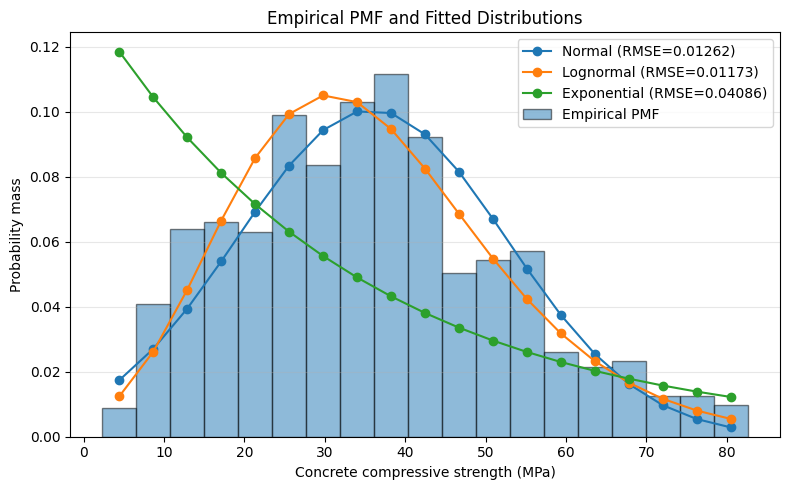

Number of bins: 19
Normal RMSE: 0.012617164122940028
Lognormal RMSE: 0.011730243602110944
Exponential RMSE: 0.040861375152641634


In [9]:
from scipy.stats import norm, lognorm, expon

hist, bin_edges = np.histogram(values, bins=bins)
pmf = hist / len(values)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bar_widths = np.diff(bin_edges)

plt.figure(figsize=(8, 5))

plt.bar(
    bin_centers,
    pmf,
    width=bar_widths,
    alpha=0.5,
    edgecolor="black",
    label="Empirical PMF"
)

plt.plot(bin_centers, normal_probs, marker="o",
         label=f"Normal (RMSE={rmse_normal:.5f})")

plt.plot(bin_centers, lognormal_probs, marker="o",
         label=f"Lognormal (RMSE={rmse_lognormal:.5f})")

plt.plot(bin_centers, exp_probs, marker="o",
         label=f"Exponential (RMSE={rmse_exp:.5f})")

plt.xlabel("Concrete compressive strength (MPa)")
plt.ylabel("Probability mass")
plt.title("Empirical PMF and Fitted Distributions")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("strength_distribution_fitting.png", dpi=300, bbox_inches="tight")
plt.show()

print("Number of bins:", bins)
print("Normal RMSE:", rmse_normal)
print("Lognormal RMSE:", rmse_lognormal)
print("Exponential RMSE:", rmse_exp)

# water & cement

- Select two numerical features from the dataset.
- Define the random variable (RV) functions and discrete value sets (DVS).
- Plot the marginal histograms for both features.
- Create a scatter plot of the two features.
- Compute the Pearson correlation coefficient.
- Construct a 3D joint PMF plot.
- Calculate σ₁, σ₂, and the covariance.
- Plot the corresponding bivariate Gaussian distribution.
- Interpret whether the Gaussian distribution provides a good model for the data.


## Correlation and Scatter Plot

In [76]:
df[["Water", "Cement"]].describe()

,Water,Cement
count,1030.000000,1030.000000
mean,181.567282,281.167864
std,21.354219,104.506364
min,121.800000,102.000000
25%,164.900000,192.375000
50%,185.000000,272.900000
75%,192.000000,350.000000
max,247.000000,540.000000


In [77]:
import matplotlib.pyplot as plt
import pandas as pd

data = df[["Water", "Cement"]].dropna()

x = data["Water"]
y = data["Cement"]

In [78]:
import numpy as np

def freedman_diaconis_bins(series):
    series = series.dropna()
    n = len(series)

    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1

    bin_width = 2 * iqr * (n ** (-1/3))

    data_range = series.max() - series.min()
    bins = int(np.ceil(data_range / bin_width))

    return bin_width, bins

water_width, water_bins = freedman_diaconis_bins(df["Water"])
cement_width, cement_bins = freedman_diaconis_bins(df["Cement"])

print("Water bin width:", water_width)
print("Water bins:", water_bins)

print("Cement bin width:", cement_width)
print("Cement bins:", cement_bins)

Water bin width: 5.366859322986169
Water bins: 24
Cement bin width: 31.215911468106828
Cement bins: 15


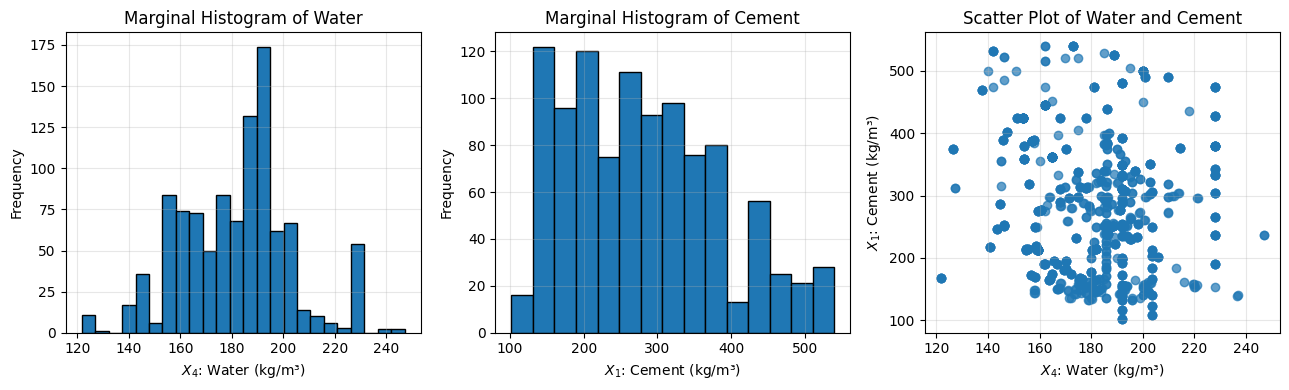

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.hist(x, bins=24, edgecolor="black")
plt.title("Marginal Histogram of Water")
plt.xlabel(r"$X_4$: Water (kg/m³)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(y, bins=15, edgecolor="black")
plt.title("Marginal Histogram of Cement")
plt.xlabel(r"$X_1$: Cement (kg/m³)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(x, y, alpha=0.7)
plt.title("Scatter Plot of Water and Cement")
plt.xlabel(r"$X_4$: Water (kg/m³)")
plt.ylabel(r"$X_1$: Cement (kg/m³)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- **Water:** Most observations are concentrated between 150 and 200 kg/m³, with a prominent peak around 190 kg/m³. The distribution appears approximately bell-shaped and resembles a weakly normal distribution.

- **Cement:** A large number of observations are concentrated around 150 kg/m³ and between 200 and 400 kg/m³. The distribution also exhibits a long right tail, suggesting a mildly right-skewed distribution.

- **Scatter plot:** No clear upward or downward linear pattern is visible. Likewise, there is no distinct line-like concentration of points. Most observations are clustered in the region Water ≈ 170–200 kg/m³ and Cement ≈ 150–350 kg/m³. Several outliers are also present. Overall, the scatter plot suggests a weak relationship and near-zero correlation between the two variables.

- **Pearson correlation:** The correlation coefficient is negative and very close to zero (|r| ≈ 0.08), indicating that the variables are nearly uncorrelated. At most, there is a very weak negative correlation (weak anticorrelation) between Water and Cement.

In [80]:
r = x.corr(y)
print("Pearson correlation:", r)

Pearson correlation: -0.0815867484641084


## joint pmf - cement & water

- **Continuous variables:** Probability Density Function (PDF)
- **Discrete variables:** Probability Mass Function (PMF)

The term *mass* is used because probability is concentrated at specific values (or within specific intervals), rather than being spread continuously over the entire domain.

### Empirical Probability

When the sample size is sufficiently large, relative frequencies provide a good approximation of probabilities.

Empirical Probability = (Number of observations in a bin) / (Total number of observations)

Therefore, the relative frequency of observations within a bin can be interpreted as an estimate of the true probability.

### Why Examine the Joint PMF?

Unlike the Pearson correlation coefficient, the empirical joint PMF provides additional information about the structure of the data. In particular, a 3D joint PMF allows us to examine:

- where the probability mass is concentrated,
- whether the distribution exhibits regular or irregular patterns,
- whether the relationship between the variables appears weak or strong,
- and whether a Gaussian model is likely to provide a reasonable approximation of the joint distribution.

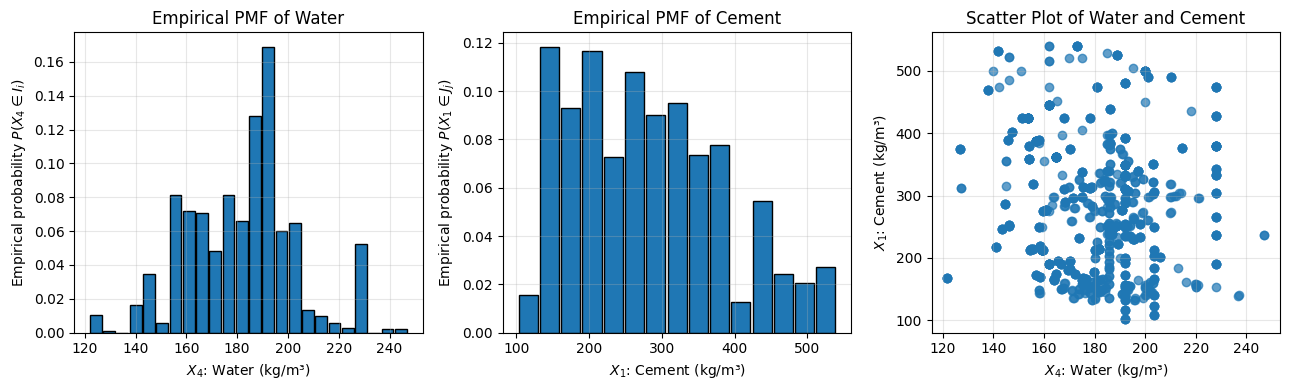

In [81]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
water_counts, water_edges = np.histogram(x, bins=24)
water_pmf = water_counts / water_counts.sum()
water_centers = (water_edges[:-1] + water_edges[1:]) / 2
water_width = water_edges[1] - water_edges[0]

plt.bar(water_centers, water_pmf, width=water_width * 0.9, edgecolor="black")
plt.title("Empirical PMF of Water")
plt.xlabel(r"$X_4$: Water (kg/m³)")
plt.ylabel(r"Empirical probability $P(X_4 \in I_i)$")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
cement_counts, cement_edges = np.histogram(y, bins=15)
cement_pmf = cement_counts / cement_counts.sum()
cement_centers = (cement_edges[:-1] + cement_edges[1:]) / 2
cement_width = cement_edges[1] - cement_edges[0]

plt.bar(cement_centers, cement_pmf, width=cement_width * 0.9, edgecolor="black")
plt.title("Empirical PMF of Cement")
plt.xlabel(r"$X_1$: Cement (kg/m³)")
plt.ylabel(r"Empirical probability $P(X_1 \in J_j)$")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(x, y, alpha=0.7)
plt.title("Scatter Plot of Water and Cement")
plt.xlabel(r"$X_4$: Water (kg/m³)")
plt.ylabel(r"$X_1$: Cement (kg/m³)")
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()

Water-Cement의 scatter plot이 전체적으로 퍼져있음. 즉, water을 안다고 cement를 거의 예측 못함. 이건 독립에 가까운 모습.

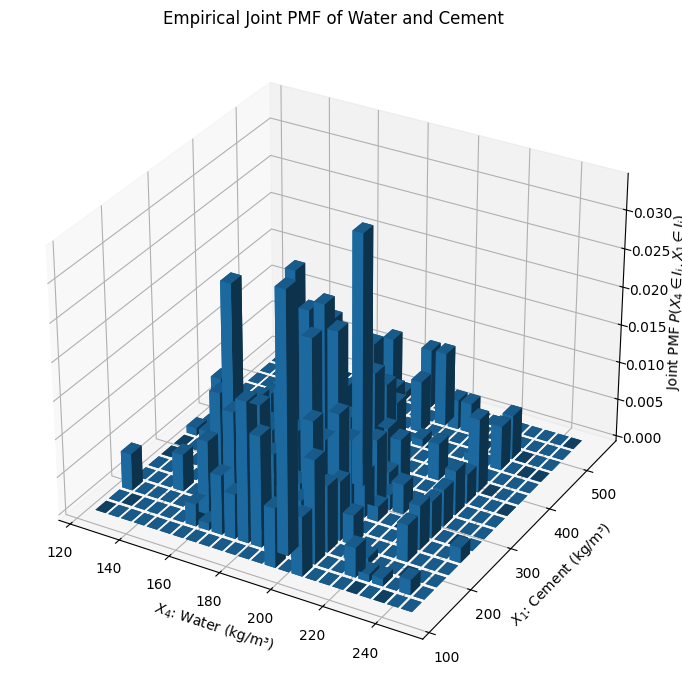

In [82]:
import numpy as np
import matplotlib.pyplot as plt

data = df[["Water", "Cement"]].dropna()

x = data["Water"]
y = data["Cement"]

water_bins = 24
cement_bins = 15

hist2d, x_edges, y_edges = np.histogram2d(
    x,
    y,
    bins=[water_bins, cement_bins]
)

joint_pmf = hist2d / hist2d.sum()

x_centers = (x_edges[:-1] + x_edges[1:]) / 2
y_centers = (y_edges[:-1] + y_edges[1:]) / 2

Xc, Yc = np.meshgrid(x_centers, y_centers, indexing="ij")

dx = (x_edges[1] - x_edges[0]) * 0.8
dy = (y_edges[1] - y_edges[0]) * 0.8

xpos = Xc.ravel()
ypos = Yc.ravel()
zpos = np.zeros_like(xpos)

dz = joint_pmf.ravel()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)

ax.set_title("Empirical Joint PMF of Water and Cement")
ax.set_xlabel(r"$X_4$: Water (kg/m³)")
ax.set_ylabel(r"$X_1$: Cement (kg/m³)")
ax.set_zlabel(r"Joint PMF $P(X_4 \in I_i, X_1 \in J_j)$")

plt.tight_layout()
plt.show()

- The empirical joint distribution of Water and Cement appears irregular and sparse. A smooth and symmetric distribution would typically resemble a single hill-shaped peak centered around one dominant region.

- The higher probability masses do not align along a diagonal direction. Therefore, the joint distribution does not suggest a strong linear relationship between the two variables.

- For a bivariate Gaussian model to provide a good approximation, the joint distribution should generally exhibit a smooth elliptical or bell-shaped structure centered around a single peak. In contrast, the empirical joint PMF contains multiple local peaks and a considerable number of low-probability or empty bins, indicating departures from the assumptions of a simple Gaussian model.

## 2-variate gaussian

### Bivariate Gaussian Model

- A smooth probabilistic model constructed from the empirical mean vector, variances, and covariance.

- A bivariate Gaussian distribution typically forms a single smooth hill-shaped surface.

Its main characteristics are:

- a single central peak,
- probability density that decreases smoothly away from the center,
- an approximately circular or axis-aligned elliptical shape when the covariance is small,
- and a tilted elliptical shape when the covariance is large.

To define a bivariate Gaussian model, the following quantities are required:

- the mean vector,
- the covariance matrix.


In [83]:
import numpy as np
import pandas as pd

data = df[["Water", "Cement"]].dropna()

x = data["Water"]
y = data["Cement"]

mu_1 = x.mean()
mu_2 = y.mean()

sigma_1 = x.std(ddof=1)
sigma_2 = y.std(ddof=1)

covariance = np.cov(x, y, ddof=1)[0, 1]

print("Mean of Water (mu_1):", mu_1)
print("Mean of Cement (mu_2):", mu_2)
print("Standard deviation of Water (sigma_1):", sigma_1)
print("Standard deviation of Cement (sigma_2):", sigma_2)
print("Covariance Cov[Water, Cement]:", covariance)

Mean of Water (mu_1): 181.56728155339806
Mean of Cement (mu_2): 281.16786407766995
Standard deviation of Water (sigma_1): 21.354218565032525
Standard deviation of Cement (sigma_2): 104.50636449481543
Covariance Cov[Water, Cement]: -182.07320989366613


In [84]:
mean_vector = np.array([mu_1, mu_2])

cov_matrix = np.array([
    [sigma_1**2, covariance],
    [covariance, sigma_2**2]
])

print("Mean vector:")
print(mean_vector)

print("Covariance matrix:")
print(cov_matrix)

Mean vector:
[181.56728155 281.16786408]
Covariance matrix:
[[  456.00265052  -182.07320989]
 [ -182.07320989 10921.58021992]]


- Cement variance is much larger than Water variance.

- The Gaussian surface is expected to be more spread out in the Cement direction than in the Water direction.

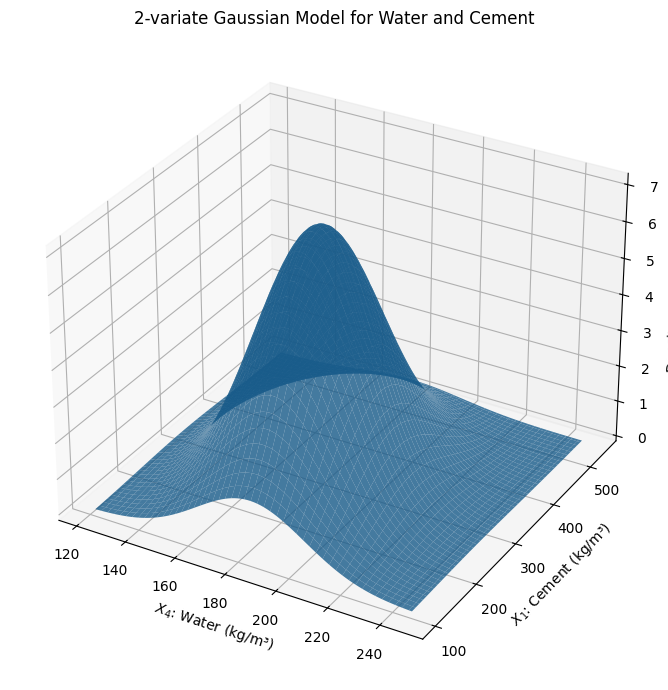

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Grid over the range of Water and Cement
x_grid = np.linspace(x.min(), x.max(), 100)
y_grid = np.linspace(y.min(), y.max(), 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Combine grid points into coordinate pairs
pos = np.dstack((X_grid, Y_grid))

# Define 2-variate Gaussian using empirical mean and covariance
rv = multivariate_normal(mean=mean_vector, cov=cov_matrix)

# Gaussian density values
Z = rv.pdf(pos)

# 3D surface plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X_grid, Y_grid, Z, alpha=0.8)

ax.set_title("2-variate Gaussian Model for Water and Cement")
ax.set_xlabel(r"$X_4$: Water (kg/m³)")
ax.set_ylabel(r"$X_1$: Cement (kg/m³)")
ax.set_zlabel(r"Density $p_{X_1,X_2}(x_1,x_2)$")

plt.tight_layout()
plt.show()

네 empirical joint PMF는 아까 이렇게 보였어:

여러 local peak가 있음
빈 bin도 많음
불규칙하고 sparse함
하나의 매끄러운 산 모양은 아님

반면 fitted Gaussian은:

하나의 중심
smooth한 surface
symmetric/elliptical structure
평균, 분산, 공분산만 반영

그래서 결론은:

2-variate Gaussian은 rough approximation으로는 가능하지만, empirical joint PMF를 잘 설명하는 모델이라고 보기는 어렵다.

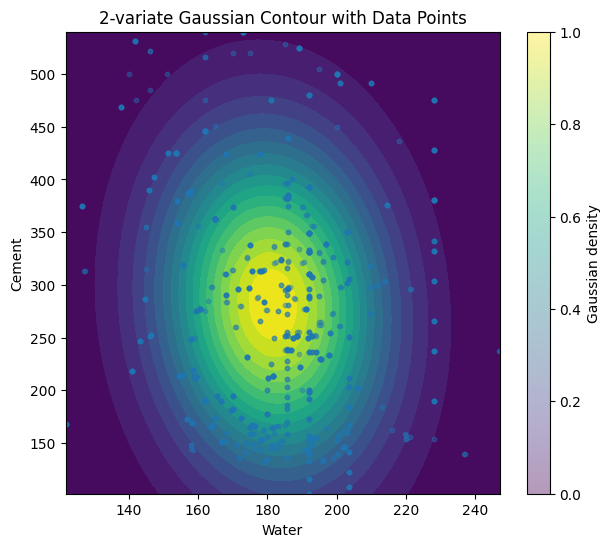

In [86]:
plt.figure(figsize=(7, 6))

plt.contourf(X_grid, Y_grid, Z, levels=20)
plt.scatter(x, y, s=10, alpha=0.4)

plt.xlabel("Water")
plt.ylabel("Cement")
plt.title("2-variate Gaussian Contour with Data Points")
plt.colorbar(label="Gaussian density")

plt.show()

- The Gaussian contours are nearly vertically elongated ellipses.

- The Pearson correlation coefficient between Water and Cement is very small (r = -0.08), and neither the scatter plot nor the empirical joint PMF reveals a clear dependence structure. Therefore, the observed data do not exhibit patterns that strongly contradict an independence assumption.

- Why can we not simply conclude that the variables are independent? Independence requires that

  P(X, Y) = P(X)P(Y)

  for all possible combinations of x and y.

- If Water is discretized into 24 bins and Cement into 15 bins, this condition would need to be verified for all

  24 × 15 = 360

  cells of the joint distribution.

- In practice, the available data constitute only a finite sample, and the PMF obtained from the data is an empirical PMF rather than the true underlying PMF. Consequently, it is difficult to formally prove complete independence from the observed data alone.

- More rigorous approaches for assessing independence include the chi-square test of independence and information-theoretic measures such as mutual information.

# correlation matrix

In [87]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
Blast Furnace Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
Fly Ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
Coarse Aggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
Fine Aggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
Age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
Concrete compressive strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


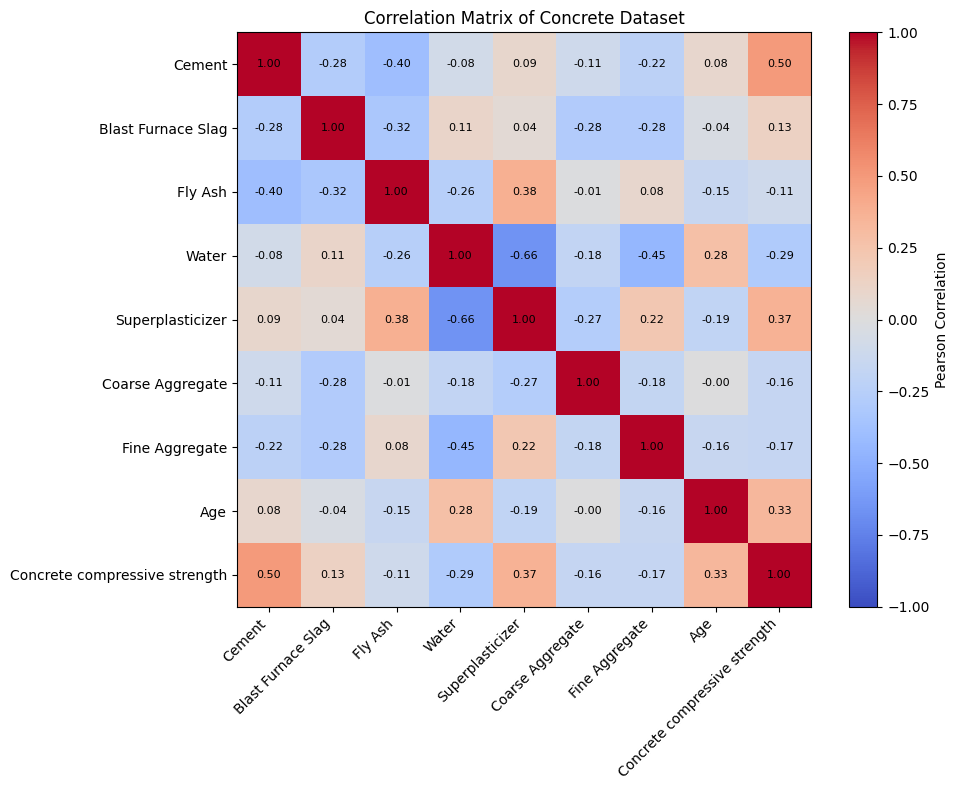

In [89]:
plt.figure(figsize=(10,8))

im = plt.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, label="Pearson Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix of Concrete Dataset")

plt.tight_layout()
plt.show()

In [90]:
print(df.columns.tolist())

['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concrete compressive strength']


In [91]:
target_corr = (
    corr_matrix["Concrete compressive strength"]
    .drop("Concrete compressive strength")
    .sort_values(ascending=False)
)

print(target_corr)

Cement                0.497832
Superplasticizer      0.366079
Age                   0.328873
Blast Furnace Slag    0.134829
Fly Ash              -0.105755
Coarse Aggregate     -0.164935
Fine Aggregate       -0.167241
Water                -0.289633
Name: Concrete compressive strength, dtype: float64


In [92]:
target_corr_df = pd.DataFrame({
    "Variable": target_corr.index,
    "Correlation with Concrete compressive strength": target_corr.values
})

target_corr_df

,Variable,Correlation with Concrete compressive strength
0,Cement,0.497832
1,Superplasticizer,0.366079
2,Age,0.328873
3,Blast Furnace Slag,0.134829
4,Fly Ash,-0.105755
5,Coarse Aggregate,-0.164935
6,Fine Aggregate,-0.167241
7,Water,-0.289633


# strength & cement

## Correlation and Scatter Plot

In [93]:
df[["Concrete compressive strength", "Cement"]].describe()

,Concrete compressive strength,Cement
count,1030.000000,1030.000000
mean,35.817961,281.167864
std,16.705742,104.506364
min,2.330000,102.000000
25%,23.710000,192.375000
50%,34.445000,272.900000
75%,46.135000,350.000000
max,82.600000,540.000000


In [94]:
import matplotlib.pyplot as plt
import pandas as pd

data = df[["Concrete compressive strength", "Cement"]].dropna()

x = data["Concrete compressive strength"]
y = data["Cement"]

In [95]:
import numpy as np

def freedman_diaconis_bins(series):
    series = series.dropna()
    n = len(series)

    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1

    bin_width = 2 * iqr * (n ** (-1/3))

    data_range = series.max() - series.min()
    bins = int(np.ceil(data_range / bin_width))

    return bin_width, bins

strength_width, strength_bins = freedman_diaconis_bins(df["Concrete compressive strength"])
cement_width, cement_bins = freedman_diaconis_bins(df["Cement"])

print("Strength bin width:", strength_width)
print("Strength bins:", strength_bins)

print("Cement bin width:", cement_width)
print("Cement bins:", cement_bins)

Strength bin width: 4.441026579998704
Strength bins: 19
Cement bin width: 31.215911468106828
Cement bins: 15


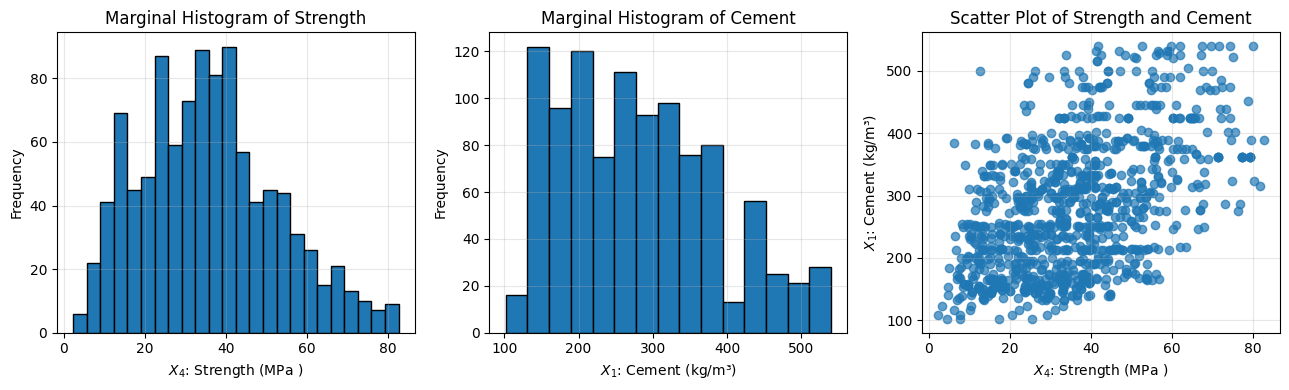

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 4))

# Strength histogram
plt.subplot(1, 3, 1)
plt.hist(x, bins=24, edgecolor="black")
plt.title("Marginal Histogram of Strength")
plt.xlabel(r"$X_4$: Strength (MPa)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

# Cement histogram
plt.subplot(1, 3, 2)
plt.hist(y, bins=15, edgecolor="black")
plt.title("Marginal Histogram of Cement")
plt.xlabel(r"$X_1$: Cement (kg/m³)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

# Scatter plot
plt.subplot(1, 3, 3)
plt.scatter(x, y, alpha=0.7)
plt.title("Scatter Plot of Strength and Cement")
plt.xlabel(r"$X_4$: Strength (MPa)")
plt.ylabel(r"$X_1$: Cement (kg/m³)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [97]:
r = x.corr(y)
print("Pearson correlation:", r)

Pearson correlation: 0.4978319193241573


- Cement and Concrete Compressive Strength exhibit a moderate positive correlation.

- The scatter plot shows a general tendency for compressive strength to increase as cement content increases. However, the relationship is far from perfectly linear.

- For example, when the cement content is around 300 kg/m³, the observed strength values range approximately from 15 to 60 MPa. Similarly, for cement contents around 400 kg/m³, the strength values vary from about 13 to 80 MPa.

- This substantial dispersion indicates that cement alone is insufficient to explain variations in compressive strength. Instead, multiple mixture components and curing conditions jointly influence the target variable.

## joint pmf - cement & Strength


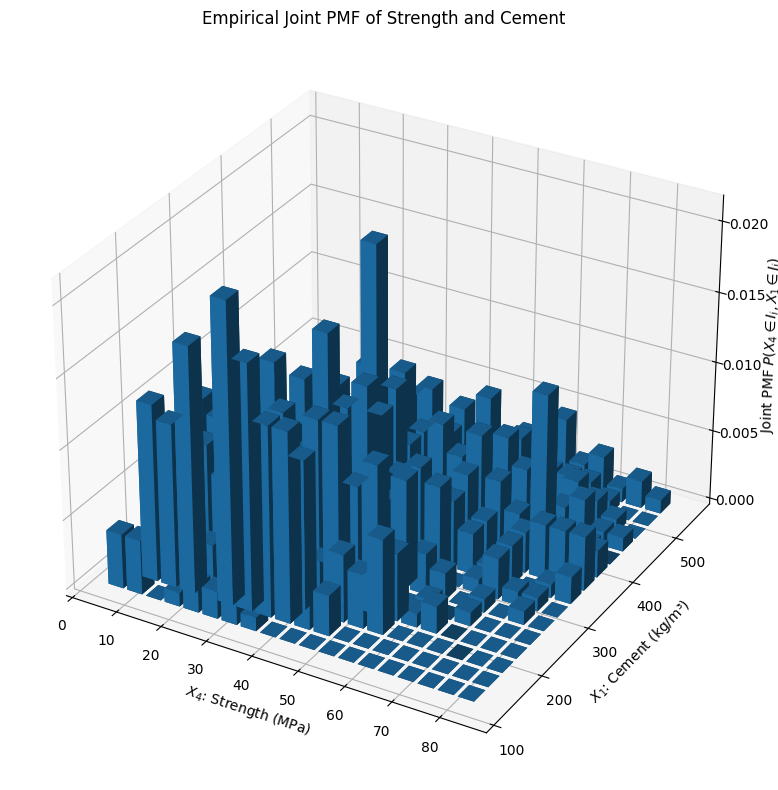

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

data = df[["Concrete compressive strength", "Cement"]].dropna()

x = data["Concrete compressive strength"]
y = data["Cement"]

strength_bins = 19
cement_bins = 15

hist2d, x_edges, y_edges = np.histogram2d(
    x,
    y,
    bins=[strength_bins, cement_bins]
)

joint_pmf = hist2d / hist2d.sum()

x_centers = (x_edges[:-1] + x_edges[1:]) / 2
y_centers = (y_edges[:-1] + y_edges[1:]) / 2

Xc, Yc = np.meshgrid(x_centers, y_centers, indexing="ij")

dx = (x_edges[1] - x_edges[0]) * 0.8
dy = (y_edges[1] - y_edges[0]) * 0.8

xpos = Xc.ravel()
ypos = Yc.ravel()
zpos = np.zeros_like(xpos)

dz = joint_pmf.ravel()

fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)
ax.zaxis.set_major_locator(MaxNLocator(5))
ax.zaxis.set_major_formatter(
    FormatStrFormatter('%.3f')
)

ax.set_title("Empirical Joint PMF of Strength and Cement")
ax.set_xlabel(r"$X_4$: Strength (MPa)")
ax.set_ylabel(r"$X_1$: Cement (kg/m³)")
ax.set_zlabel(r"Joint PMF $P(X_4 \in I_i, X_1 \in J_j)$")

plt.tight_layout()
plt.show()

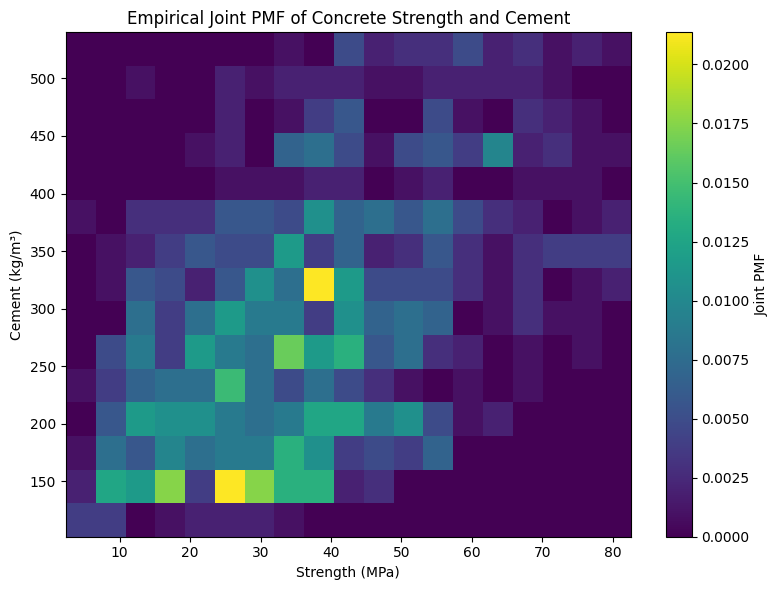

In [99]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    joint_pmf.T,
    origin="lower",
    aspect="auto",
    extent=[
        x_edges[0],
        x_edges[-1],
        y_edges[0],
        y_edges[-1]
    ]
)

plt.colorbar(im, label="Joint PMF")

plt.xlabel("Strength (MPa)")
plt.ylabel("Cement (kg/m³)")

plt.title(
    "Empirical Joint PMF of Concrete Strength and Cement"
)

plt.tight_layout()
plt.show()

- The brighter regions of the heatmap appear to extend from the lower-left toward the upper-right. This pattern suggests that larger compressive strength values tend to be associated with larger cement contents, indicating a positive relationship between the variables.

- The diagonal structure visible in the heatmap suggests that the two variables are unlikely to be independent.

- Multiple strength values are observed for the same cement content. This indicates substantial dispersion in the data and implies that the conditional distribution of strength given cement content has a relatively large spread.

- Overall, the Pearson correlation coefficient (r ≈ 0.50) indicates a moderate positive correlation between Cement and Concrete Compressive Strength. However, the scatter plot also reveals considerable dispersion. Therefore, although cement is an important predictor, it is not sufficient to explain compressive strength on its own. This suggests that multivariate modeling is required to adequately capture the variability in the target variable.

## 2-variate gaussian


In [100]:
import numpy as np
import pandas as pd

data = df[["Concrete compressive strength", "Cement"]].dropna()

x = data["Concrete compressive strength"]
y = data["Cement"]

mu_1 = x.mean()
mu_2 = y.mean()

sigma_1 = x.std(ddof=1)
sigma_2 = y.std(ddof=1)

covariance = np.cov(x, y, ddof=1)[0, 1]

print("Mean of Strength (mu_1):", mu_1)
print("Mean of Cement (mu_2):", mu_2)
print("Standard deviation of Strength (sigma_1):", sigma_1)
print("Standard deviation of Cement (sigma_2):", sigma_2)
print("Covariance Cov[Strength, Cement]:", covariance)

Mean of Strength (mu_1): 35.817961165048544
Mean of Cement (mu_2): 281.16786407766995
Standard deviation of Strength (sigma_1): 16.705741961912505
Standard deviation of Cement (sigma_2): 104.50636449481543
Covariance Cov[Strength, Cement]: 869.1430218800417


In [101]:
mean_vector = np.array([mu_1, mu_2])

cov_matrix = np.array([
    [sigma_1**2, covariance],
    [covariance, sigma_2**2]
])

print("Mean vector:")
print(mean_vector)

print("Covariance matrix:")
print(cov_matrix)

Mean vector:
[ 35.81796117 281.16786408]
Covariance matrix:
[[  279.0818145    869.14302188]
 [  869.14302188 10921.58021992]]


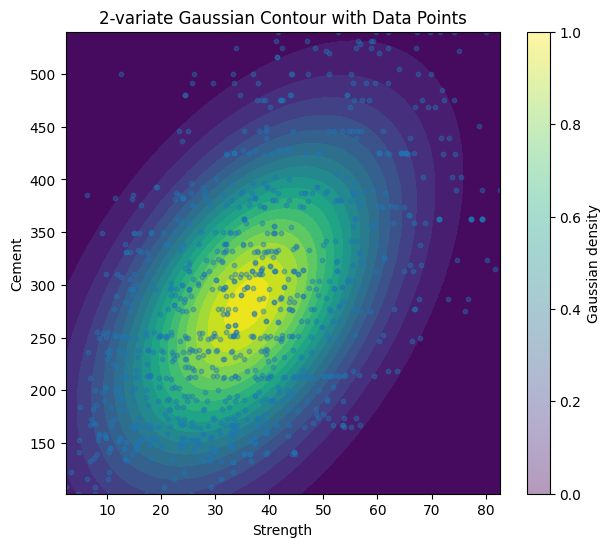

In [102]:
plt.figure(figsize=(7, 6))

x_grid = np.linspace(x.min(), x.max(), 100)
y_grid = np.linspace(y.min(), y.max(), 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

pos = np.dstack((X_grid, Y_grid))

rv = multivariate_normal(mean=mean_vector, cov=cov_matrix)

Z = rv.pdf(pos)

plt.contourf(X_grid, Y_grid, Z, levels=20)
plt.scatter(x, y, s=10, alpha=0.4)

plt.xlabel("Strength")
plt.ylabel("Cement")
plt.title("2-variate Gaussian Contour with Data Points")
plt.colorbar(label="Gaussian density")

plt.show()

- The brightest region corresponds approximately to the center of the data distribution, i.e., the area around the empirical mean values.

- The highest concentration of observations is located around:
  - Strength ≈ 35–40 MPa
  - Cement ≈ 280–320 kg/m³

- If the correlation coefficient were close to zero, the Gaussian contours would be expected to spread primarily in the vertical and horizontal directions, with little or no diagonal orientation.

- Instead, the contours form a tilted elliptical shape extending from the lower-left toward the upper-right, which is consistent with the positive correlation observed between Cement and Concrete Compressive Strength.

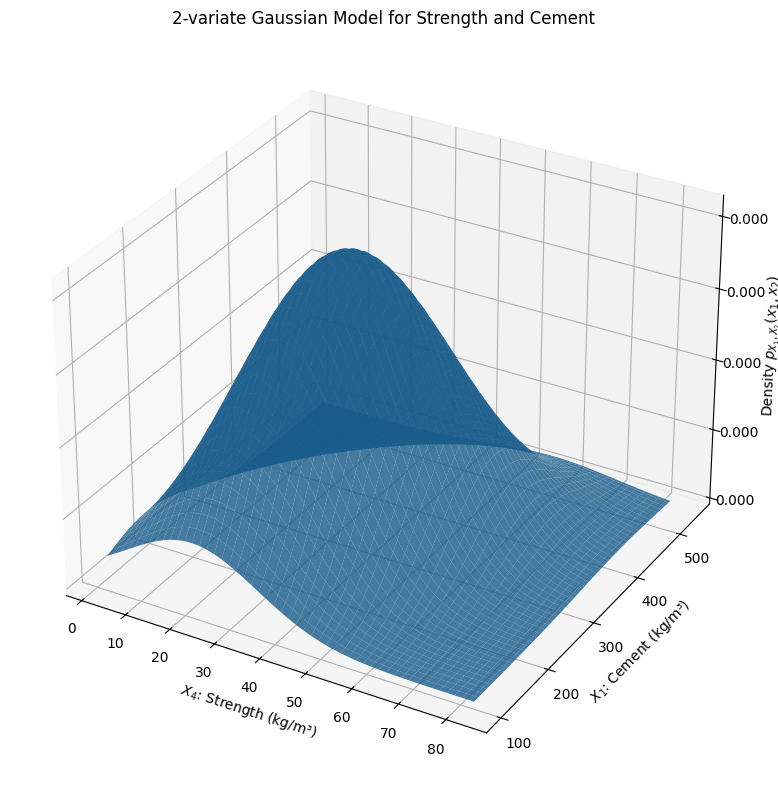

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

x_grid = np.linspace(x.min(), x.max(), 100)
y_grid = np.linspace(y.min(), y.max(), 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

pos = np.dstack((X_grid, Y_grid))

rv = multivariate_normal(mean=mean_vector, cov=cov_matrix)

Z = rv.pdf(pos)

fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X_grid, Y_grid, Z, alpha=0.8)
ax.zaxis.set_major_locator(MaxNLocator(5))
ax.zaxis.set_major_formatter(
    FormatStrFormatter('%.3f')
)

ax.set_title("2-variate Gaussian Model for Strength and Cement")
ax.set_xlabel(r"$X_4$: Strength (kg/m³)")
ax.set_ylabel(r"$X_1$: Cement (kg/m³)")
ax.set_zlabel(r"Density $p_{X_1,X_2}(x_1,x_2)$")

plt.tight_layout()
plt.show()

### What the Gaussian Model Fails to Capture

- The empirical data exhibit multiple local clusters and irregular concentration patterns, whereas a Gaussian model assumes a single smooth peak centered around one dominant location.

- Consequently, the Gaussian model captures the overall positive trend but fails to represent local structures visible in the empirical distribution.

- A bivariate Gaussian model assumes

  \[
  (X,Y) \sim N(\mu,\Sigma)
  \]

  and therefore always produces a distribution with:
  - a single center (the mean),
  - a single peak,
  - and smooth elliptical contours.

- When the empirical data contain multiple peaks or clusters, the Gaussian model effectively averages them into one large hill-shaped structure because it is determined solely by the mean vector and covariance matrix.

- If multiple peaks or clusters need to be represented explicitly, a Gaussian Mixture Model (GMM) would be more appropriate.

### Comparison with the Water–Cement Pair

- The Cement–Strength pair appears more Gaussian-like than the Water–Cement pair.

- In the Water–Cement scatter plot, the observations are broadly dispersed and resemble a diffuse cloud without a clear dominant direction.

- In contrast, the Cement–Strength scatter plot exhibits an overall upward trend.

- Since a Gaussian model always constructs a single elliptical dependence structure from the mean vector and covariance matrix, it aligns more naturally with the dominant orientation observed in the Cement–Strength data.

- Therefore, the Gaussian model provides a reasonable description of the overall dependence structure for the Cement–Strength pair, even though it does not reproduce all local features of the empirical distribution.

### Interpretation of the Gaussian Assumption

- The Gaussian assumption states that

  \[
  (X,Y) \sim N(\mu,\Sigma)
  \]

  meaning that the relationship between the variables can be characterized primarily through the mean vector, variances, and covariance.

- For the Water–Cement pair, the mean and covariance alone provide little information about the underlying relationship.

- For the Cement–Strength pair, however, the mean and covariance are sufficient to capture the main characteristic of the data, namely the overall positive association between the two variables.





# water & Superplasticizer

## Correlation and Scatter Plot

In [104]:
df[["Water", "Superplasticizer"]].describe()

,Water,Superplasticizer
count,1030.000000,1030.000000
mean,181.567282,6.204660
std,21.354219,5.973841
min,121.800000,0.000000
25%,164.900000,0.000000
50%,185.000000,6.400000
75%,192.000000,10.200000
max,247.000000,32.200000


**ｍｏｒｅ ｔｈａｎ ２５ ‰ ｏｆ superplasticizer = 0**

In [106]:
import matplotlib.pyplot as plt
import pandas as pd

data = df[["Water", "Superplasticizer"]].dropna()

x = data["Water"]
y = data["Superplasticizer"]

In [107]:
import numpy as np

def freedman_diaconis_bins(series):
    series = series.dropna()
    n = len(series)

    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1

    bin_width = 2 * iqr * (n ** (-1/3))

    data_range = series.max() - series.min()
    bins = int(np.ceil(data_range / bin_width))

    return bin_width, bins

water_width, water_bins = freedman_diaconis_bins(df["Water"])
superplasticizer_width, superplasticizer_bins = freedman_diaconis_bins(df["Superplasticizer"])

print("water bin width:", water_width)
print("water bins:", water_bins)

print("Superplasticizer bin width:", superplasticizer_width)
print("Superplasticizer bins:", superplasticizer_bins)

water bin width: 5.366859322986169
water bins: 24
Superplasticizer bin width: 2.0199987119726543
Superplasticizer bins: 16


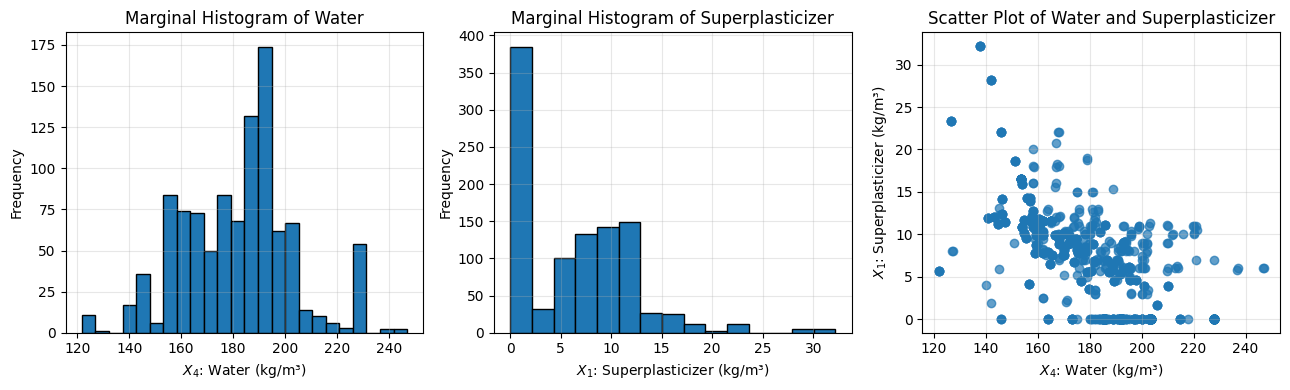

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.hist(x, bins=24, edgecolor="black")
plt.title("Marginal Histogram of Water")
plt.xlabel(r"$X_4$: Water (kg/m³)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(y, bins=15, edgecolor="black")
plt.title("Marginal Histogram of Superplasticizer")
plt.xlabel(r"$X_1$: Superplasticizer (kg/m³)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(x, y, alpha=0.7)
plt.title("Scatter Plot of Water and Superplasticizer")
plt.xlabel(r"$X_4$: Water (kg/m³)")
plt.ylabel(r"$X_1$: Superplasticizer (kg/m³)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The marginal distribution of Superplasticizer is highly skewed, with a substantial concentration of observations at or near zero.


In [109]:
r = x.corr(y)
print("Pearson correlation:", r)

Pearson correlation: -0.6575329076284463


The strong negative correlation suggests a substitution effect between water and superplasticizer. Mixtures containing larger amounts of superplasticizer tend to require less water while maintaining workability

## joint pmf - cement & water


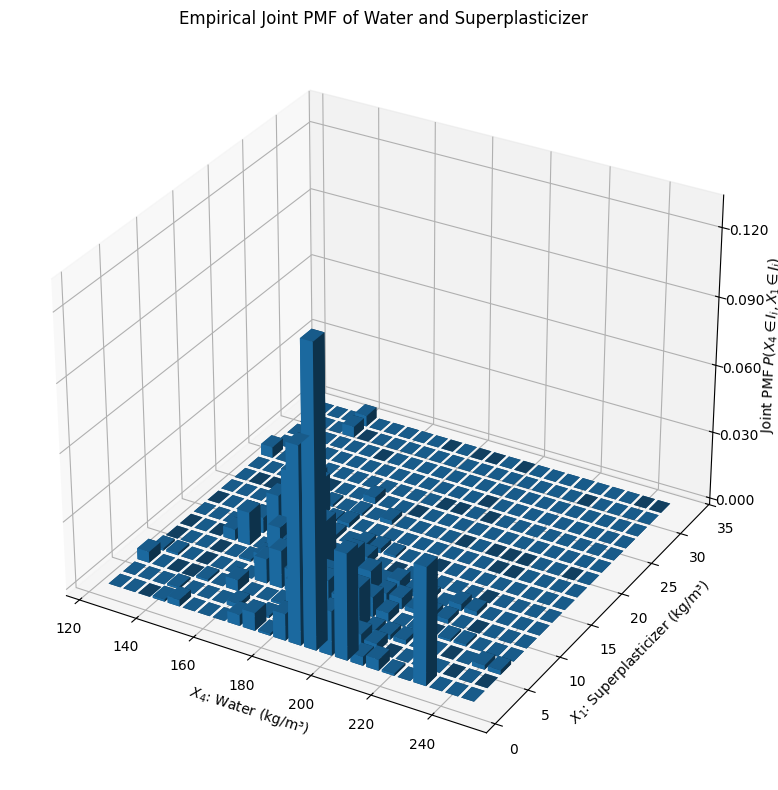

In [110]:
"import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

data = df[["Water", "Cement"]].dropna()

x = data["Water"]
y = data["Cement"]

water_bins = 19
cement_bins = 15

hist2d, x_edges, y_edges = np.histogram2d(
    x,
    y,
    bins=[water_bins, cement_bins]
)

joint_pmf = hist2d / hist2d.sum()

x_centers = (x_edges[:-1] + x_edges[1:]) / 2
y_centers = (y_edges[:-1] + y_edges[1:]) / 2

Xc, Yc = np.meshgrid(x_centers, y_centers, indexing="ij")

dx = (x_edges[1] - x_edges[0]) * 0.8
dy = (y_edges[1] - y_edges[0]) * 0.8

xpos = Xc.ravel()
ypos = Yc.ravel()
zpos = np.zeros_like(xpos)

dz = joint_pmf.ravel()

fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)
ax.zaxis.set_major_locator(MaxNLocator(5))
ax.zaxis.set_major_formatter(
    FormatStrFormatter('%.3f')
)

ax.set_title("Empirical Joint PMF of water and Cement")
ax.set_xlabel(r"$X_4$: Water (kg/m³)")
ax.set_ylabel(r"$X_1$: Superplasticizer (kg/m³)")
ax.set_zlabel(r"Joint PMF $P(X_4 \in I_i, X_1 \in J_j)$")

plt.tight_layout()
plt.show()

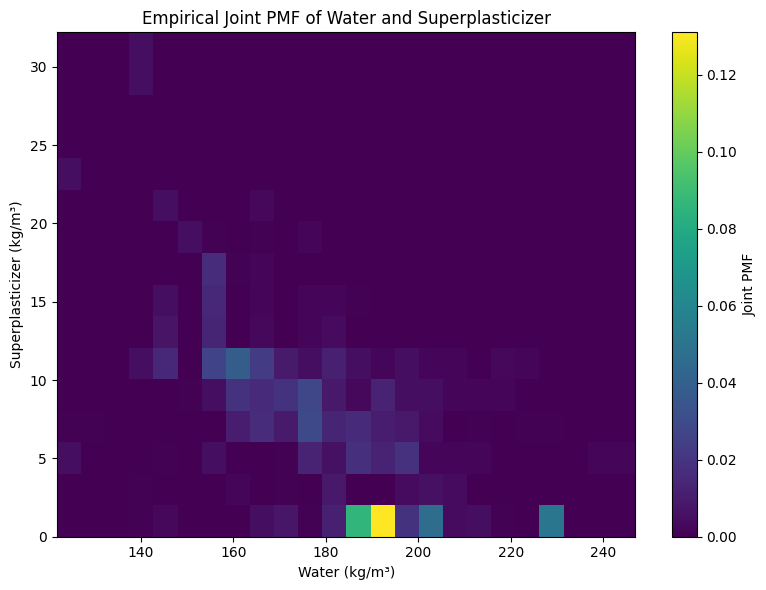

In [111]:
plt.figure(figsize=(8,6))

im = plt.imshow(
    joint_pmf.T,
    origin="lower",
    aspect="auto",
    extent=[
        x_edges[0],
        x_edges[-1],
        y_edges[0],
        y_edges[-1]
    ]
)

plt.colorbar(im, label="Joint PMF")

plt.xlabel("Water (kg/m³)")
plt.ylabel("Superplasticizer (kg/m³)")

plt.title(
    "Empirical Joint PMF of Water and Superplasticizer"
)

plt.tight_layout()
plt.show()

- Bright regions follow a downward diagonal pattern (upper-left to lower-right), consistent with the negative Pearson correlation.

- Dispersion is smaller than in the Water–Cement pair. The observations are concentrated along a negative trend rather than being randomly scattered.

- The brightest hotspot (largest local peak) is located around Water ≈ 190 kg/m³ and Superplasticizer ≈ 0 kg/m³.




## 2-variate gaussian

In [10]:
import numpy as np
import pandas as pd

data = df[["Water", "Superplasticizer"]].dropna()

x = data["Water"]
y = data["Superplasticizer"]

mu_1 = x.mean()
mu_2 = y.mean()

sigma_1 = x.std(ddof=1)
sigma_2 = y.std(ddof=1)

covariance = np.cov(x, y, ddof=1)[0, 1]

print("Mean of Strength (mu_1):", mu_1)
print("Mean of Cement (mu_2):", mu_2)
print("Standard deviation of Strength (sigma_1):", sigma_1)
print("Standard deviation of Cement (sigma_2):", sigma_2)
print("Covariance Cov[Strength, Cement]:", covariance)

Mean of Strength (mu_1): 181.56728155339806
Mean of Cement (mu_2): 6.204660194174758
Standard deviation of Strength (sigma_1): 21.354218565032525
Standard deviation of Cement (sigma_2): 5.973841392485506
Covariance Cov[Strength, Cement]: -83.87931287799442


In [113]:
mean_vector = np.array([mu_1, mu_2])

cov_matrix = np.array([
    [sigma_1**2, covariance],
    [covariance, sigma_2**2]
])

print("Mean vector:")
print(mean_vector)

print("Covariance matrix:")
print(cov_matrix)

Mean vector:
[181.56728155   6.20466019]
Covariance matrix:
[[456.00265052 -83.87931288]
 [-83.87931288  35.68678098]]


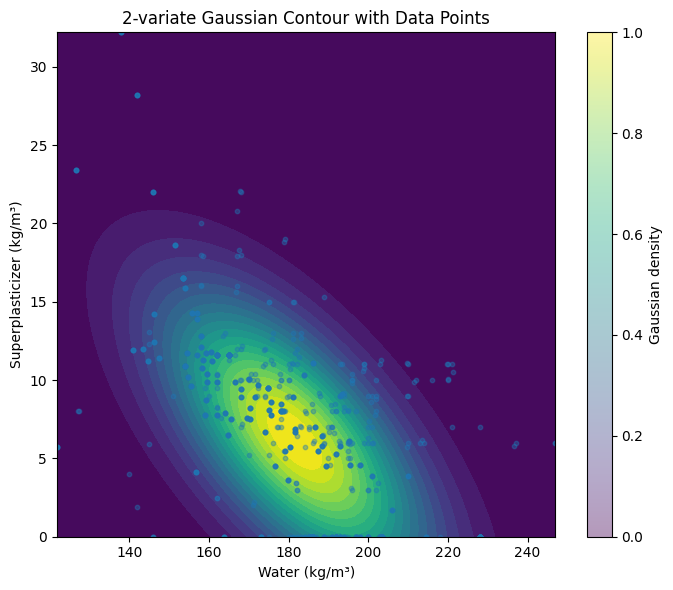

In [114]:
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import numpy as np

# Create grid for Water and Superplasticizer
x_grid = np.linspace(x.min(), x.max(), 100)
y_grid = np.linspace(y.min(), y.max(), 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Combine grid points
pos = np.dstack((X_grid, Y_grid))

# Define bivariate Gaussian model
rv = multivariate_normal(
    mean=mean_vector,
    cov=cov_matrix
)

# Gaussian density on the grid
Z = rv.pdf(pos)

# Normalize density for visualization
Z = Z / Z.max()

# Plot contour with data points
plt.figure(figsize=(7, 6))

plt.contourf(X_grid, Y_grid, Z, levels=20)
plt.scatter(x, y, s=10, alpha=0.4)

plt.xlabel("Water (kg/m³)")
plt.ylabel("Superplasticizer (kg/m³)")
plt.title("2-variate Gaussian Contour with Data Points")
plt.colorbar(label="Gaussian density")

plt.tight_layout()
plt.show()

- The brightest region corresponds approximately to the center of the data distribution, i.e., the area around the empirical mean values.

- The highest concentration of observations is located around:
  - Water ≈ 180–190 kg/m³
  - Superplasticizer ≈ 5–7 kg/m³

- The Pearson correlation coefficient is −0.658. Consequently, the Gaussian contours are elongated along a downward-sloping direction (↘). If the correlation were close to zero, the contours would be nearly circular or aligned with the coordinate axes.

### What the Gaussian Model Fails to Capture

- The most prominent feature of the empirical heatmap is the large peak near Superplasticizer = 0. However, this feature is not reproduced by the Gaussian model.

- The reason is that the Gaussian distribution is centered around the empirical mean (μ₂ = 6.2) and spreads probability mass smoothly around that center.

- In contrast, the empirical data are heavily concentrated near zero, resulting in a strongly asymmetric distribution.

- Therefore, the Gaussian model captures the overall negative relationship between Water and Superplasticizer, but it fails to represent the pronounced concentration of observations near Superplasticizer = 0.

### Comparison with the Cement–Strength Pair

- The Water–Superplasticizer pair exhibits a stronger correlation, smaller dispersion, and a more pronounced diagonal structure than the Cement–Strength pair.

- As a result, the Gaussian model provides a better approximation of the overall dependence structure for Water–Superplasticizer than for Cement–Strength.

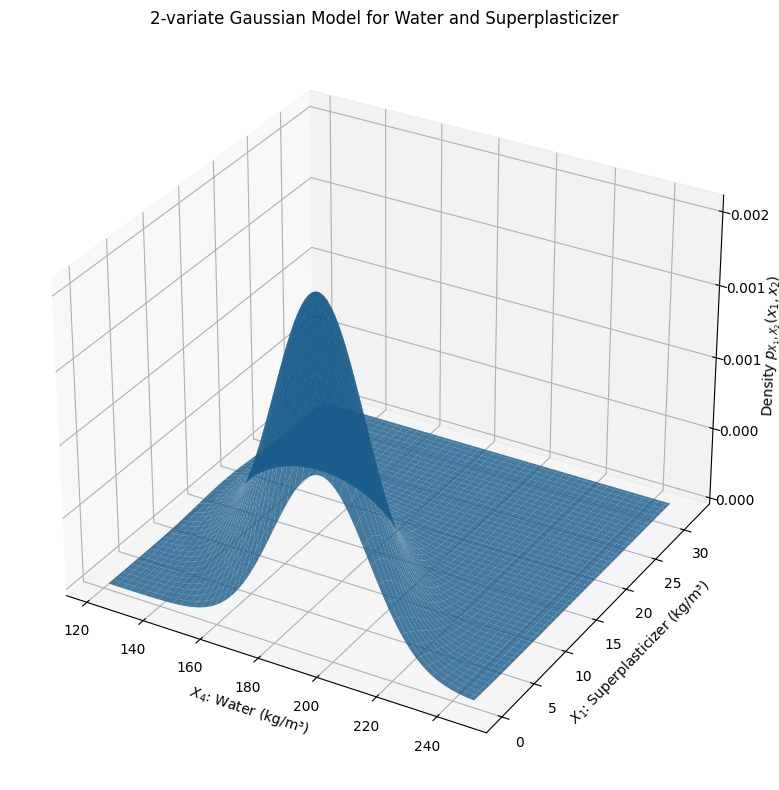

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

x_grid = np.linspace(x.min(), x.max(), 100)
y_grid = np.linspace(y.min(), y.max(), 100)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

pos = np.dstack((X_grid, Y_grid))

rv = multivariate_normal(mean=mean_vector, cov=cov_matrix)

Z = rv.pdf(pos)

fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X_grid, Y_grid, Z, alpha=0.8)
ax.zaxis.set_major_locator(MaxNLocator(5))
ax.zaxis.set_major_formatter(
    FormatStrFormatter('%.3f')
)

ax.set_title("2-variate Gaussian Model for Water and Superplasticizer")
ax.set_xlabel(r"$X_4$: Water (kg/m³)")
ax.set_ylabel(r"$X_1$: Superplasticizer (kg/m³)")
ax.set_zlabel(r"Density $p_{X_1,X_2}(x_1,x_2)$")

plt.tight_layout()
plt.show()